In [ ]:
# Importación de librerías necesarias para el análisis y las visualizaciones
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Carga del dataset: GitHub Innovation Graph, cantidad de desarrolladores
# por lenguaje, país y trimestre (fuente oficial: github.com/github/innovationgraph)
df = pd.read_csv('https://raw.githubusercontent.com/github/innovationgraph/main/data/languages.csv')
df

,num_pushers,language,language_type,iso2_code,year,quarter
0,2066,HTML,markup,AE,2020,1
1,1627,CSS,markup,AE,2020,1
2,288,Jupyter Notebook,markup,AE,2020,1
3,108,Vue,markup,AE,2020,1
4,1734,JavaScript,programming,AE,2020,1
...,...,...,...,...,...,...
180333,175,Procfile,programming,ZW,2026,1
180334,152,CMake,programming,ZW,2026,1
180335,149,Dart,programming,ZW,2026,1
180336,144,C#,programming,ZW,2026,1


In [3]:
# Identificar valores nulos por columna
df.isnull().sum()

num_pushers       0
language          0
language_type     0
iso2_code        84
year              0
quarter           0
dtype: int64

In [4]:
# Identificar registros duplicados
df.duplicated().sum()

np.int64(0)

In [5]:
# Perfilado: tipos de datos y cantidad de valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180338 entries, 0 to 180337
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   num_pushers    180338 non-null  int64
 1   language       180338 non-null  str  
 2   language_type  180338 non-null  str  
 3   iso2_code      180254 non-null  str  
 4   year           180338 non-null  int64
 5   quarter        180338 non-null  int64
dtypes: int64(3), str(3)
memory usage: 8.3 MB


In [6]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,num_pushers,year,quarter
count,1.803380e+05,180338.000000,180338.000000
mean,3.373004e+03,2022.930336,2.452522
std,1.993471e+04,1.784462,1.141745
min,1.010000e+02,2020.000000,1.000000
25%,1.840000e+02,2021.000000,1.000000
50%,4.010000e+02,2023.000000,2.000000
75%,1.339000e+03,2024.000000,3.000000
max,1.245924e+06,2026.000000,4.000000


In [7]:
# Valores únicos de la columna language_type, para detectar categorías
df['language_type'].unique()

<StringArray>
['markup', 'programming', 'data', 'prose']
Length: 4, dtype: str

In [8]:
# Cantidad de lenguajes distintos y de países distintos en el dataset
df['language'].nunique(), df['iso2_code'].nunique()

(404, 184)

In [9]:
# Revisar qué lenguajes tienen registros con iso2_code nulo
# (para entender si son errores o datos realmente ausentes)
df[df['iso2_code'].isnull()]['language'].unique()

<StringArray>
[      'HTML',        'CSS', 'JavaScript',  'Ballerina',     'Python',
       'Java', 'Dockerfile', 'TypeScript',     'Kotlin',      'Shell',
        'PHP']
Length: 11, dtype: str

In [10]:
# Limpieza: eliminar duplicados
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [11]:
# Normalizar variables categóricas: quitar espacios y pasar a minúsculas
df['language'] = df['language'].str.strip()
df['language_type'] = df['language_type'].str.lower()

In [12]:
# Imputar valores faltantes de iso2_code con un valor explícito
df['iso2_code'] = df['iso2_code'].fillna('Sin identificar')
df.isnull().sum()

num_pushers      0
language         0
language_type    0
iso2_code        0
year             0
quarter          0
dtype: int64

In [13]:
# Filtrar solo los lenguajes de programación (se excluyen markup, data y prose,
# como HTML, CSS, JSON o Markdown, que no son lenguajes de programación en sí)
df_prog = df[df['language_type'] == 'programming'].copy()
df_prog.shape

(144144, 6)

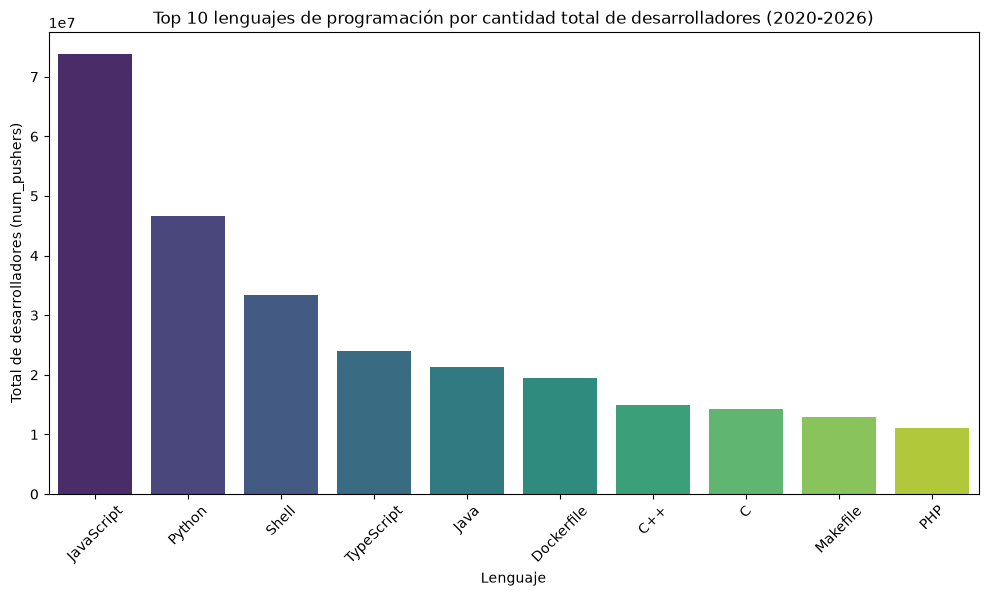

In [14]:
# Barplot: comparar los 10 lenguajes con más desarrolladores en total (2020-2026)
top_lang = df_prog.groupby('language')['num_pushers'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_lang, x='language', y='num_pushers', hue='language', palette='viridis', legend=False)
plt.title("Top 10 lenguajes de programación por cantidad total de desarrolladores (2020-2026)")
plt.xlabel("Lenguaje")
plt.ylabel("Total de desarrolladores (num_pushers)")
plt.xticks(rotation=45)
plt.show()

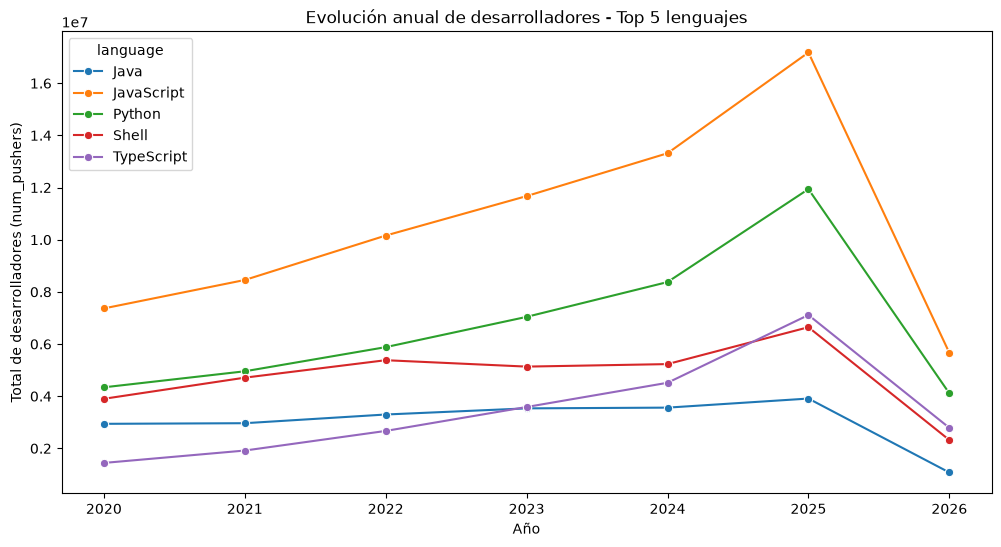

In [15]:
# Gráfico de líneas: evolución año a año de los 5 lenguajes más usados
top5 = top_lang['language'].head(5).tolist()
evol = df_prog[df_prog['language'].isin(top5)].groupby(['year', 'language'])['num_pushers'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=evol, x='year', y='num_pushers', hue='language', marker='o')
plt.title("Evolución anual de desarrolladores - Top 5 lenguajes")
plt.xlabel("Año")
plt.ylabel("Total de desarrolladores (num_pushers)")
plt.show()

In [16]:
# Insight: lenguajes con mayor crecimiento y mayor caída entre 2020 y 2025,
# filtrando solo lenguajes que ya tenían una base relevante en 2020
# (evita que lenguajes muy chicos distorsionen el ranking con % de cambio enormes)
growth = df_prog.groupby(['language', 'year'])['num_pushers'].sum().unstack()
growth = growth[[2020, 2025]].dropna()
growth['change_pct'] = (growth[2025] - growth[2020]) / growth[2020] * 100

growth_relevant = growth[growth[2020] >= 1000]

top_growth = growth_relevant.sort_values('change_pct', ascending=False).head(5)
top_decline = growth_relevant.sort_values('change_pct').head(5)

print("Lenguajes con mayor crecimiento 2020 -> 2025 (entre los ya establecidos):")
print(top_growth[['change_pct']])
print("\nLenguajes con mayor caída 2020 -> 2025 (entre los ya establecidos):")
print(top_decline[['change_pct']])

Lenguajes con mayor crecimiento 2020 -> 2025 (entre los ya establecidos):
year                change_pct
language                      
BitBake            2524.410707
Zig                2251.083159
Nix                1108.517029
Open Policy Agent   953.353659
Solidity            951.659117

Lenguajes con mayor caída 2020 -> 2025 (entre los ya establecidos):
year      change_pct
language            
SQLPL     -96.031239
Rebol     -84.270346
LOLCODE   -84.036538
AspectJ   -82.521490
Coq       -76.355391
